In [121]:
import pandas as pd
import matplotlib.pyplot as plt
data = {
    "Customer_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                    11, 12, 13, 14, 15],

    "Age": [25, 30, 35, 28, 42, 38, 150, 45, 32, 29,
            200, 40, 36, 27, 33],

    "Account_Number": [10001, 10002, 10003, 10004, 10005,
                       10006, 10007, 10008, 10009, 10010,
                       10011, 10012, 10013, 10014, 10015],

    "Balance": [25000, 45000, 30000, 55000, 60000,
                35000, 5000000, 42000, 38000, 28000,
                7500000, 48000, 32000, 52000, 40000],

    "Email": [
        "a@gmail.com", "b@gmail.com", "c@gmail.com",
        "d@gmail.com", "e@gmail.com", "f@gmail.com",
        "g@gmail.com", "h@gmail.com", "i@gmail.com",
        "j@gmail.com", "k@gmail.com", "l@gmail.com",
        "m@gmail.com", "n@gmail.com", "o@gmail.com"
    ]
}

df = pd.DataFrame(data)

print(df)

# check is that is outlier in Balance with box plot
# find out outlier
# then replace outlier with ?
# after handle the outlier box plot show show

    Customer_ID  Age  Account_Number  Balance        Email
0             1   25           10001    25000  a@gmail.com
1             2   30           10002    45000  b@gmail.com
2             3   35           10003    30000  c@gmail.com
3             4   28           10004    55000  d@gmail.com
4             5   42           10005    60000  e@gmail.com
5             6   38           10006    35000  f@gmail.com
6             7  150           10007  5000000  g@gmail.com
7             8   45           10008    42000  h@gmail.com
8             9   32           10009    38000  i@gmail.com
9            10   29           10010    28000  j@gmail.com
10           11  200           10011  7500000  k@gmail.com
11           12   40           10012    48000  l@gmail.com
12           13   36           10013    32000  m@gmail.com
13           14   27           10014    52000  n@gmail.com
14           15   33           10015    40000  o@gmail.com


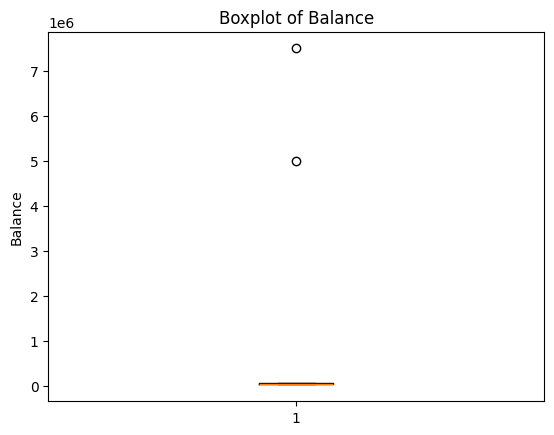

In [122]:
# check is that is outlier in Balance with box plot
df = pd.DataFrame(data)
plt.boxplot(df["Balance"])
plt.title("Boxplot of Balance")
plt.ylabel("Balance")
plt.show()

In [123]:
# find out outlier
q1=df["Balance"].quantile(0.25)

q3=df["Balance"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Balance"] < lower) | (df["Balance"] > upper)])

    Customer_ID  Age  Account_Number  Balance        Email
6             7  150           10007  5000000  g@gmail.com
10           11  200           10011  7500000  k@gmail.com


In [124]:
# then replace outlier with Maximum
df.loc[df["Balance"] > upper, "Balance"] = df["Balance"].max()
df["Balance"] = df["Balance"].fillna(df["Balance"].max())
print(df)

    Customer_ID  Age  Account_Number  Balance        Email
0             1   25           10001    25000  a@gmail.com
1             2   30           10002    45000  b@gmail.com
2             3   35           10003    30000  c@gmail.com
3             4   28           10004    55000  d@gmail.com
4             5   42           10005    60000  e@gmail.com
5             6   38           10006    35000  f@gmail.com
6             7  150           10007  7500000  g@gmail.com
7             8   45           10008    42000  h@gmail.com
8             9   32           10009    38000  i@gmail.com
9            10   29           10010    28000  j@gmail.com
10           11  200           10011  7500000  k@gmail.com
11           12   40           10012    48000  l@gmail.com
12           13   36           10013    32000  m@gmail.com
13           14   27           10014    52000  n@gmail.com
14           15   33           10015    40000  o@gmail.com


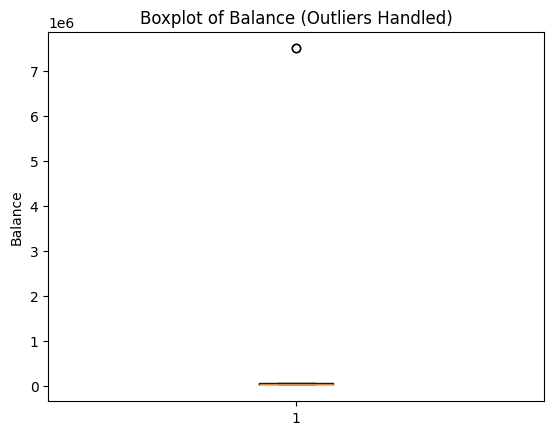

In [125]:
plt.boxplot(df["Balance"])
plt.title("Boxplot of Balance (Outliers Handled)")
plt.ylabel("Balance")
plt.show()

In [126]:
import pandas as pd



loan_data = {

    "Loan_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],

    "Gender": ["Male", "Female", "Male", "Male", "Female",

               "Female", "Male", "Female", "Male", "Female"],

    "Age": [25, 32, None, 28, 35, 40, 150, 50, 38, None],

    "Income": [25000, 40000, 60000, None, 45000,


               55000, 32000, 75000, "unknown", 28000],

    "Loan_Amount": [100000, 150000, 250000, 120000, None,

                    200000, 110000, 300000, 220000, 90000],

    "Credit_Score": [650, 720, 780, 600, 700,

                     None, 620, 800, 710, 1200],

    "Loan_Status": ["Approved", "Approved", "Approved", "Rejected",

                    "Approved", "Approved", "Rejected", "Approved",

                    "Rejected","Approved"]

}



df = pd.DataFrame(loan_data)



print(df)

   Loan_ID  Gender    Age   Income  Loan_Amount  Credit_Score Loan_Status
0      101    Male   25.0    25000     100000.0         650.0    Approved
1      102  Female   32.0    40000     150000.0         720.0    Approved
2      103    Male    NaN    60000     250000.0         780.0    Approved
3      104    Male   28.0     None     120000.0         600.0    Rejected
4      105  Female   35.0    45000          NaN         700.0    Approved
5      106  Female   40.0    55000     200000.0           NaN    Approved
6      107    Male  150.0    32000     110000.0         620.0    Rejected
7      108  Female   50.0    75000     300000.0         800.0    Approved
8      109    Male   38.0  unknown     220000.0         710.0    Rejected
9      110  Female    NaN    28000      90000.0        1200.0    Approved


In [127]:
df["Gender"]=df["Gender"].map({

    "Male":0,

    "Female":1
})
print (df)

   Loan_ID  Gender    Age   Income  Loan_Amount  Credit_Score Loan_Status
0      101       0   25.0    25000     100000.0         650.0    Approved
1      102       1   32.0    40000     150000.0         720.0    Approved
2      103       0    NaN    60000     250000.0         780.0    Approved
3      104       0   28.0     None     120000.0         600.0    Rejected
4      105       1   35.0    45000          NaN         700.0    Approved
5      106       1   40.0    55000     200000.0           NaN    Approved
6      107       0  150.0    32000     110000.0         620.0    Rejected
7      108       1   50.0    75000     300000.0         800.0    Approved
8      109       0   38.0  unknown     220000.0         710.0    Rejected
9      110       1    NaN    28000      90000.0        1200.0    Approved


In [128]:
df["Loan_Status"]=df["Loan_Status"].map({"Rejected":0,"Approved":1})
print(df)

   Loan_ID  Gender    Age   Income  Loan_Amount  Credit_Score  Loan_Status
0      101       0   25.0    25000     100000.0         650.0            1
1      102       1   32.0    40000     150000.0         720.0            1
2      103       0    NaN    60000     250000.0         780.0            1
3      104       0   28.0     None     120000.0         600.0            0
4      105       1   35.0    45000          NaN         700.0            1
5      106       1   40.0    55000     200000.0           NaN            1
6      107       0  150.0    32000     110000.0         620.0            0
7      108       1   50.0    75000     300000.0         800.0            1
8      109       0   38.0  unknown     220000.0         710.0            0
9      110       1    NaN    28000      90000.0        1200.0            1


In [129]:
# ordinal Encoding

import pandas as pd

data = {
    "User_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
                111, 112, 113, 114, 115, 116, 117, 118, 119, 120],

    "Name": ["Amit", "Priya", "Rahul", "Sneha", "Vikas",
             "Neha", "Rohan", "Anjali", "Karan", "Pooja",
             "Arjun", "Meena", "Sahil", "Kavita", "Nitin",
             "Riya", "Varun", "Simran", "Aditya", "Isha"],

    "Age": [25, 32, 28, 41, 35, 29, 45, 26, 38, 31,
            24, 36, 27, 43, 30, 34, 40, 23, 37, 28],

    "City": ["Pune", "Delhi", "Mumbai", "Pune", "Delhi",
             "Mumbai", "Pune", "Delhi", "Mumbai", "Pune",
             "Delhi", "Mumbai", "Pune", "Delhi", "Mumbai",
             "Pune", "Delhi", "Mumbai", "Pune", "Delhi"],

    "Income": [35000, 52000, 45000, 68000, 55000,
               42000, 75000, 38000, 62000, 48000,
               32000, 58000, 40000, 72000, 50000,
               46000, 65000, 30000, 54000, 60000]
}

df = pd.DataFrame(data)


df["EncodeCity"]=df["City"].map(
    {"Pune":1,
     "Delhi":2,
     "Mumbai":3}

)
print(df)

# pune 1   mumbai 2  delhi 3

    User_ID    Name  Age    City  Income  EncodeCity
0       101    Amit   25    Pune   35000           1
1       102   Priya   32   Delhi   52000           2
2       103   Rahul   28  Mumbai   45000           3
3       104   Sneha   41    Pune   68000           1
4       105   Vikas   35   Delhi   55000           2
5       106    Neha   29  Mumbai   42000           3
6       107   Rohan   45    Pune   75000           1
7       108  Anjali   26   Delhi   38000           2
8       109   Karan   38  Mumbai   62000           3
9       110   Pooja   31    Pune   48000           1
10      111   Arjun   24   Delhi   32000           2
11      112   Meena   36  Mumbai   58000           3
12      113   Sahil   27    Pune   40000           1
13      114  Kavita   43   Delhi   72000           2
14      115   Nitin   30  Mumbai   50000           3
15      116    Riya   34    Pune   46000           1
16      117   Varun   40   Delhi   65000           2
17      118  Simran   23  Mumbai   30000      

In [130]:
# One Hot Encoding

import pandas as pd

data = {
    "User_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
                111, 112, 113, 114, 115, 116, 117, 118, 119, 120],

    "Name": ["Amit", "Priya", "Rahul", "Sneha", "Vikas",
             "Neha", "Rohan", "Anjali", "Karan", "Pooja",
             "Arjun", "Meena", "Sahil", "Kavita", "Nitin",
             "Riya", "Varun", "Simran", "Aditya", "Isha"],

    "Age": [25, 32, 28, 41, 35, 29, 45, 26, 38, 31,
            24, 36, 27, 43, 30, 34, 40, 23, 37, 28],

    "City": ["Pune", "Delhi", "Mumbai", "Pune", "Delhi",
             "Mumbai", "Pune", "Delhi", "Mumbai", "Pune",
             "Delhi", "Mumbai", "Pune", "Delhi", "Mumbai",
             "Pune", "Delhi", "Mumbai", "Pune", "Delhi"],

    "Income": [35000, 52000, 45000, 68000, 55000,
               42000, 75000, 38000, 62000, 48000,
               32000, 58000, 40000, 72000, 50000,
               46000, 65000, 30000, 54000, 60000],

    "Education": [
        "Degree", "Master", "Post Master", "PhD", "Master",
        "Degree", "PhD", "Master", "Post Master", "Degree",
        "Master", "Post Master", "Degree", "PhD", "Master",
        "Degree", "Post Master", "Degree", "PhD", "Master"
    ]
}

df = pd.DataFrame(data)

df_encoded=pd.get_dummies(df,columns=["City"])
print(df_encoded)


#print(df)

    User_ID    Name  Age  Income    Education  City_Delhi  City_Mumbai  \
0       101    Amit   25   35000       Degree       False        False   
1       102   Priya   32   52000       Master        True        False   
2       103   Rahul   28   45000  Post Master       False         True   
3       104   Sneha   41   68000          PhD       False        False   
4       105   Vikas   35   55000       Master        True        False   
5       106    Neha   29   42000       Degree       False         True   
6       107   Rohan   45   75000          PhD       False        False   
7       108  Anjali   26   38000       Master        True        False   
8       109   Karan   38   62000  Post Master       False         True   
9       110   Pooja   31   48000       Degree       False        False   
10      111   Arjun   24   32000       Master        True        False   
11      112   Meena   36   58000  Post Master       False         True   
12      113   Sahil   27   40000      

In [131]:
df = pd.DataFrame(data)

df_encoded=pd.get_dummies(df,columns=["City"],dtype=int)

print(df_encoded)

    User_ID    Name  Age  Income    Education  City_Delhi  City_Mumbai  \
0       101    Amit   25   35000       Degree           0            0   
1       102   Priya   32   52000       Master           1            0   
2       103   Rahul   28   45000  Post Master           0            1   
3       104   Sneha   41   68000          PhD           0            0   
4       105   Vikas   35   55000       Master           1            0   
5       106    Neha   29   42000       Degree           0            1   
6       107   Rohan   45   75000          PhD           0            0   
7       108  Anjali   26   38000       Master           1            0   
8       109   Karan   38   62000  Post Master           0            1   
9       110   Pooja   31   48000       Degree           0            0   
10      111   Arjun   24   32000       Master           1            0   
11      112   Meena   36   58000  Post Master           0            1   
12      113   Sahil   27   40000      

**EDA process step by step** **⏭**

In [40]:
import pandas as pd

df = pd.read_csv(
    "retail_store_sales.csv",
    parse_dates=["Transaction Date"]
)

print(df)

      Transaction ID Customer ID       Category          Item  Price Per Unit  \
0        TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1        TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2        TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3        TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4        TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   
...              ...         ...            ...           ...             ...   
12570    TXN_9347481     CUST_18     Patisserie   Item_23_PAT            38.0   
12571    TXN_4009414     CUST_03      Beverages    Item_2_BEV             6.5   
12572    TXN_5306010     CUST_11       Butchers    Item_7_BUT            14.0   
12573    TXN_5167298     CUST_04      Furniture    Item_7_FUR            14.0   
12574    TXN_2407494     CUST_23           Food   Item_9_FOOD            17.0   

       Quantity  Total Spen

In [41]:
#
print(df.head())
print(df.tail())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

In [42]:
print(df.shape)

(12575, 11)


In [43]:
print(df.columns)

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')


In [44]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11362 non-null  object        
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB
None


In [45]:
print(df.describe())

       Price Per Unit      Quantity   Total Spent  \
count    11966.000000  11971.000000  11971.000000   
mean        23.365912      5.536380    129.652577   
min          5.000000      1.000000      5.000000   
25%         14.000000      3.000000     51.000000   
50%         23.000000      6.000000    108.500000   
75%         33.500000      8.000000    192.000000   
max         41.000000     10.000000    410.000000   
std         10.743519      2.857883     94.750697   

                    Transaction Date  
count                          12575  
mean   2023-07-12 20:23:41.105368064  
min              2022-01-01 00:00:00  
25%              2022-09-30 00:00:00  
50%              2023-07-13 00:00:00  
75%              2024-04-24 00:00:00  
max              2025-01-18 00:00:00  
std                              NaN  


In [46]:
print(df.isnull().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


In [47]:
print(df.isnull().mean() * 100)

Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64


In [48]:
print(df.duplicated().sum())

0


In [49]:
print(df["Category"].unique())

['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']


In [50]:
print(df["Category"].value_counts())

Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64


In [51]:
print(df["Item"].unique())

['Item_10_PAT' 'Item_17_MILK' 'Item_12_BUT' 'Item_16_BEV' 'Item_6_FOOD'
 nan 'Item_1_FOOD' 'Item_16_FUR' 'Item_22_BUT' 'Item_3_BUT' 'Item_2_FOOD'
 'Item_24_PAT' 'Item_16_MILK' 'Item_17_PAT' 'Item_13_EHE' 'Item_7_BEV'
 'Item_4_EHE' 'Item_10_FOOD' 'Item_14_FUR' 'Item_20_BUT' 'Item_25_FUR'
 'Item_14_FOOD' 'Item_22_PAT' 'Item_11_FOOD' 'Item_6_PAT' 'Item_21_EHE'
 'Item_25_BEV' 'Item_23_FOOD' 'Item_10_FUR' 'Item_11_BEV' 'Item_23_BUT'
 'Item_22_BEV' 'Item_10_EHE' 'Item_24_BUT' 'Item_8_BEV' 'Item_3_FOOD'
 'Item_12_FOOD' 'Item_16_CEA' 'Item_11_PAT' 'Item_16_BUT' 'Item_5_CEA'
 'Item_19_MILK' 'Item_23_FUR' 'Item_7_FUR' 'Item_15_CEA' 'Item_6_MILK'
 'Item_24_CEA' 'Item_22_CEA' 'Item_22_FOOD' 'Item_2_BUT' 'Item_14_PAT'
 'Item_12_PAT' 'Item_18_FOOD' 'Item_1_PAT' 'Item_4_BEV' 'Item_22_FUR'
 'Item_7_PAT' 'Item_20_CEA' 'Item_20_FOOD' 'Item_11_FUR' 'Item_25_PAT'
 'Item_7_FOOD' 'Item_21_FUR' 'Item_24_FUR' 'Item_8_MILK' 'Item_4_FOOD'
 'Item_14_BEV' 'Item_4_PAT' 'Item_4_MILK' 'Item_7_CEA' 'Item_6_EHE'
 'Ite

In [52]:
print(df["Item"].value_counts())

Item
Item_2_BEV      126
Item_25_FUR     113
Item_11_FUR     110
Item_16_MILK    109
Item_1_MILK     109
               ... 
Item_5_BEV        7
Item_13_BEV       7
Item_13_FUR       7
Item_21_PAT       6
Item_3_EHE        5
Name: count, Length: 200, dtype: int64


In [53]:
print(df["Payment Method"].unique())

['Digital Wallet' 'Credit Card' 'Cash']


In [54]:
print(df["Payment Method"].value_counts())

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64


In [55]:
print(df["Location"].unique())

['Online' 'In-store']


In [56]:
print(df["Location"].value_counts())

Location
Online      6354
In-store    6221
Name: count, dtype: int64


In [57]:
print(df["Discount Applied"].unique())

[True False nan]


In [58]:
print(df["Discount Applied"].value_counts())

Discount Applied
True     4219
False    4157
Name: count, dtype: int64


In [59]:
print(df.dtypes)

Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied            object
dtype: object


In [60]:
print(df["Transaction Date"].head())

0   2024-04-08
1   2023-07-23
2   2022-10-05
3   2022-05-07
4   2022-10-02
Name: Transaction Date, dtype: datetime64[ns]


In [61]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

print(df.dtypes)

Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied            object
dtype: object


In [62]:
print(df[["Price Per Unit", "Quantity", "Total Spent"]].isnull().sum())

Price Per Unit    609
Quantity          604
Total Spent       604
dtype: int64


In [63]:
print(df[df[["Price Per Unit", "Quantity", "Total Spent"]].isnull().any(axis=1)].head(10))

   Transaction ID Customer ID       Category Item  Price Per Unit  Quantity  \
5     TXN_7482416     CUST_09     Patisserie  NaN             NaN      10.0   
7     TXN_1372952     CUST_21      Furniture  NaN            33.5       NaN   
11    TXN_5422631     CUST_09  Milk Products  NaN             NaN       8.0   
15    TXN_1809665     CUST_14      Beverages  NaN            24.5       NaN   
17    TXN_9634894     CUST_15  Milk Products  NaN             NaN      10.0   
19    TXN_4206593     CUST_01      Furniture  NaN            35.0       NaN   
21    TXN_8685338     CUST_15  Milk Products  NaN             NaN       3.0   
25    TXN_3481599     CUST_05      Furniture  NaN            39.5       NaN   
32    TXN_1543244     CUST_20           Food  NaN             NaN       8.0   
34    TXN_1621497     CUST_06     Patisserie  NaN            23.0       NaN   

    Total Spent  Payment Method  Location Transaction Date Discount Applied  
5         200.0     Credit Card    Online       2023

In [64]:
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64


In [65]:
print(df["Discount Applied"].value_counts(dropna=False))

Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64


In [66]:
print(df[df["Discount Applied"].isnull()][
    ["Item", "Price Per Unit", "Quantity", "Total Spent", "Discount Applied"]
].head(10))

            Item  Price Per Unit  Quantity  Total Spent Discount Applied
3    Item_16_BEV            27.5       9.0        247.5              NaN
5            NaN             NaN      10.0        200.0              NaN
14  Item_16_MILK            27.5       2.0         55.0              NaN
15           NaN            24.5       NaN          NaN              NaN
17           NaN             NaN      10.0        275.0              NaN
20    Item_7_BEV            14.0       9.0        126.0              NaN
21           NaN             NaN       3.0        105.0              NaN
22    Item_4_EHE             9.5       7.0         66.5              NaN
33   Item_21_EHE            35.0       9.0        315.0              NaN
34           NaN            23.0       NaN          NaN              NaN


In [67]:
print(df.groupby("Discount Applied", dropna=False)["Total Spent"].mean())

Discount Applied
False    129.953330
True     130.491043
NaN      128.508651
Name: Total Spent, dtype: float64


In [68]:
print(df[["Price Per Unit", "Quantity", "Total Spent"]].describe())

       Price Per Unit      Quantity   Total Spent
count    11966.000000  11971.000000  11971.000000
mean        23.365912      5.536380    129.652577
std         10.743519      2.857883     94.750697
min          5.000000      1.000000      5.000000
25%         14.000000      3.000000     51.000000
50%         23.000000      6.000000    108.500000
75%         33.500000      8.000000    192.000000
max         41.000000     10.000000    410.000000


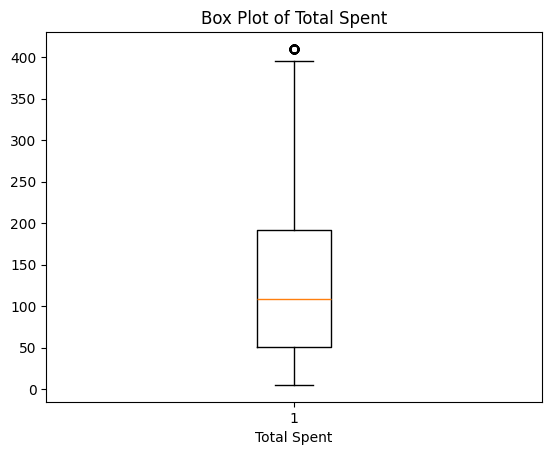

In [69]:
import matplotlib.pyplot as plt

plt.boxplot(df["Total Spent"].dropna())

plt.title("Box Plot of Total Spent")
plt.xlabel("Total Spent")
plt.show()

In [70]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 51.0
Q3: 192.0
IQR: 141.0


In [71]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -160.5
Upper Bound: 403.5


In [72]:
outliers = df[
    (df["Total Spent"] < lower) |
    (df["Total Spent"] > upper)
]

print(outliers)

      Transaction ID Customer ID                            Category  \
27       TXN_1599706     CUST_14                           Furniture   
133      TXN_2953434     CUST_25                           Furniture   
339      TXN_4374445     CUST_12                                Food   
869      TXN_1814138     CUST_06                           Beverages   
1060     TXN_3710081     CUST_25                           Furniture   
1088     TXN_1273334     CUST_22                           Beverages   
1468     TXN_1938135     CUST_17                            Butchers   
1505     TXN_8520397     CUST_12       Electric household essentials   
1568     TXN_8048041     CUST_14                            Butchers   
1950     TXN_1860120     CUST_01                           Furniture   
1983     TXN_6924479     CUST_21                          Patisserie   
2153     TXN_5338814     CUST_06                       Milk Products   
2180     TXN_1172555     CUST_08                           Bever

In [73]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 60


In [74]:
print(outliers["Total Spent"].describe())

count     60.0
mean     410.0
std        0.0
min      410.0
25%      410.0
50%      410.0
75%      410.0
max      410.0
Name: Total Spent, dtype: float64


In [75]:
print(
    outliers[["Item", "Price Per Unit", "Quantity", "Total Spent"]].head(10)
)

              Item  Price Per Unit  Quantity  Total Spent
27     Item_25_FUR            41.0      10.0        410.0
133    Item_25_FUR            41.0      10.0        410.0
339   Item_25_FOOD            41.0      10.0        410.0
869    Item_25_BEV            41.0      10.0        410.0
1060   Item_25_FUR            41.0      10.0        410.0
1088   Item_25_BEV            41.0      10.0        410.0
1468   Item_25_BUT            41.0      10.0        410.0
1505   Item_25_EHE            41.0      10.0        410.0
1568   Item_25_BUT            41.0      10.0        410.0
1950   Item_25_FUR            41.0      10.0        410.0


Uni Variant:

Therefore, our EDA conclusion
The 60 records are statistical outliers, but they do not appear to be erroneous based on this check.
👉 We should NOT delete or replace them.
We can document:
Total Spent: 60 potential outliers were detected using the IQR method. These transactions have a value of 410, which is consistent with Price Per Unit × Quantity (41 × 10). Therefore, they are treated as valid high-value transactions rather than data errors.

istogram of Total Spent
A histogram helps us see how the values are distributed — where most transactions fall and whether the distribution is skewed.

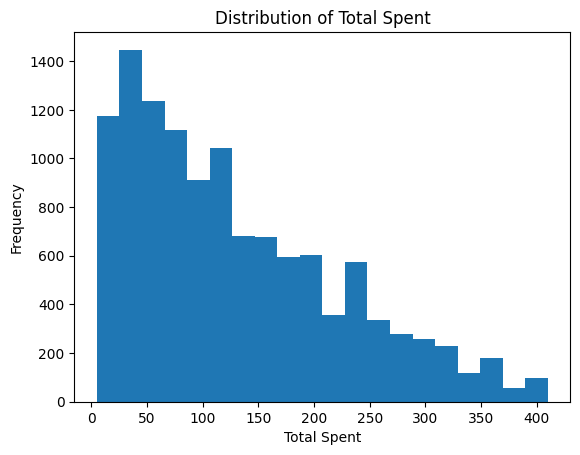

In [76]:
plt.hist(df["Total Spent"].dropna(), bins=20)

plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.show()

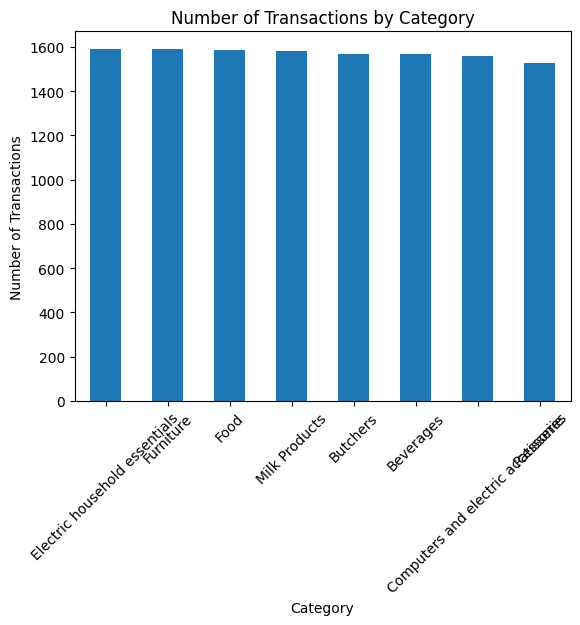

In [77]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()

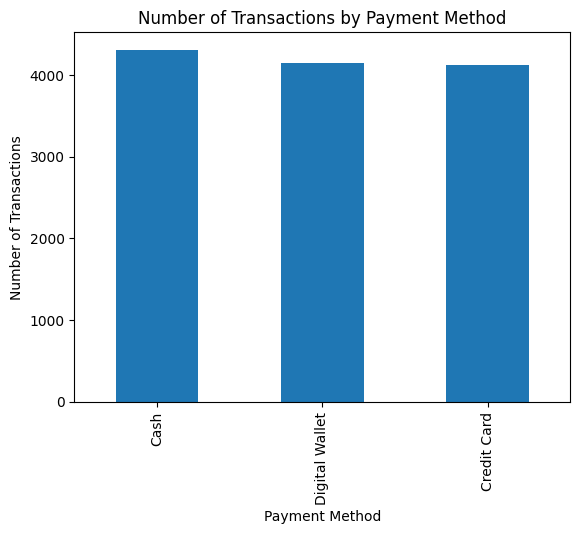

In [78]:
df["Payment Method"].value_counts().plot(kind="bar")

plt.title("Number of Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

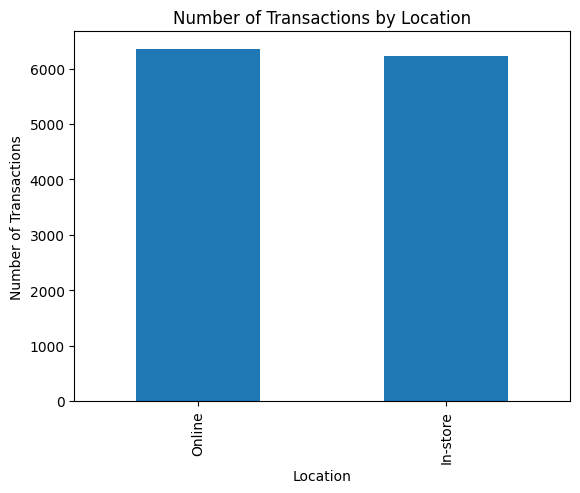

In [79]:
df["Location"].value_counts().plot(kind="bar")

plt.title("Number of Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")

plt.show()

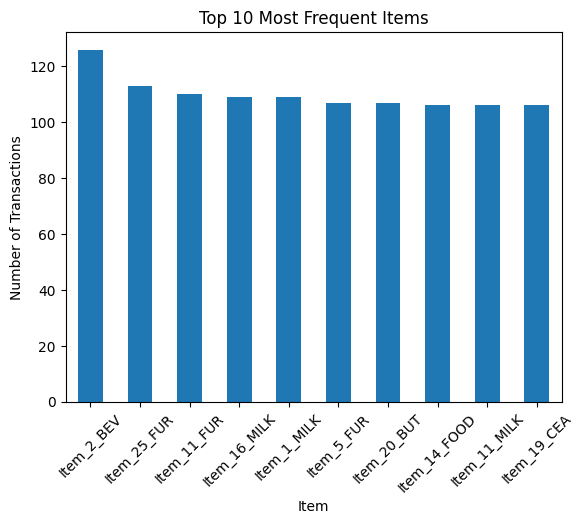

In [80]:
df["Item"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Items")
plt.xlabel("Item")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()

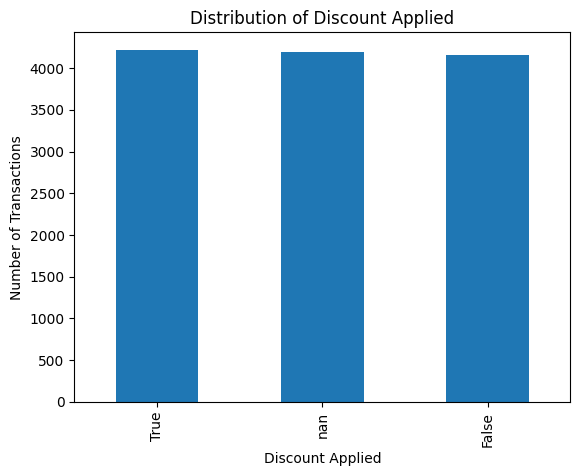

In [81]:
df["Discount Applied"].value_counts(dropna=False).plot(kind="bar")

plt.title("Distribution of Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Transactions")

plt.show()

Bivariate Analysis:How are two variables related?”

We'll cover this properly in three combinations:
1. Numerical + Numerical → Scatter plot
2. Categorical + Numerical → GroupBy / bar chart
3. Categorical + Categorical → Crosstab / count plot

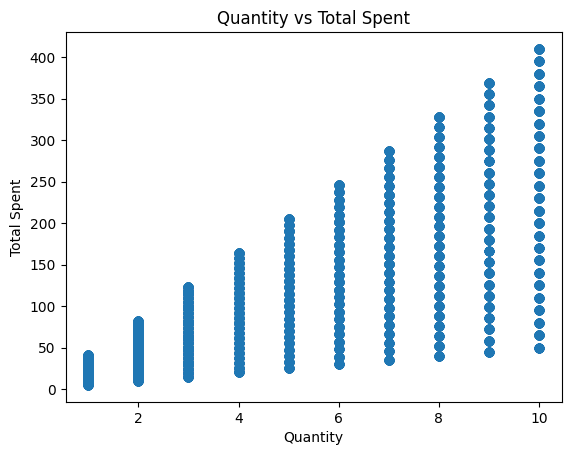

In [82]:
plt.scatter(df["Quantity"], df["Total Spent"])

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.show()

In [83]:
category_spending = df.groupby("Category")["Total Spent"].mean()

print(category_spending)

Category
Beverages                             131.716243
Butchers                              139.116310
Computers and electric accessories    129.107989
Electric household essentials         134.441623
Food                                  129.271400
Furniture                             128.072131
Milk Products                         119.042961
Patisserie                            126.416031
Name: Total Spent, dtype: float64


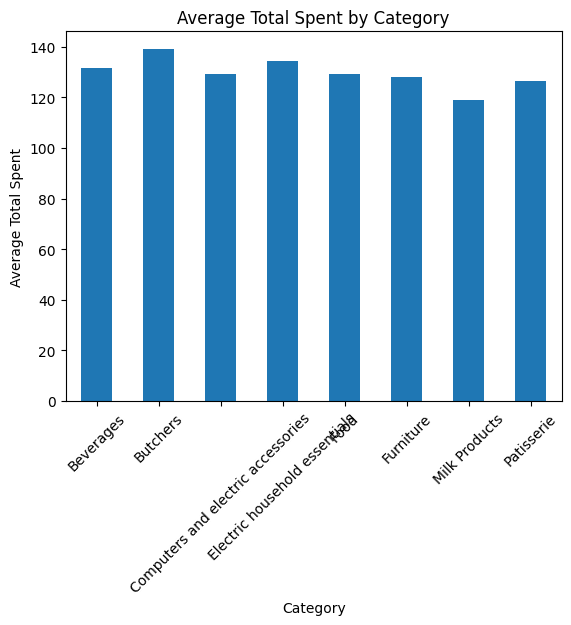

In [84]:
category_spending.plot(kind="bar")

plt.title("Average Total Spent by Category")
plt.xlabel("Category")
plt.ylabel("Average Total Spent")

plt.xticks(rotation=45)
plt.show()

In [85]:
category_payment = pd.crosstab(
    df["Category"],
    df["Payment Method"]
)

print(category_payment)

Payment Method                      Cash  Credit Card  Digital Wallet
Category                                                             
Beverages                            580          479             508
Butchers                             520          553             495
Computers and electric accessories   547          519             492
Electric household essentials        539          487             565
Food                                 560          506             522
Furniture                            527          530             534
Milk Products                        527          541             516
Patisserie                           510          506             512


e have two categorical variables:
- Category
- Payment Method
pd.crosstab() creates a frequency table showing how many transactions belong to each combination.
o we are asking:
For each category, how many customers used each payment method?

This is different from our previous groupby + mean:
Categorical + Numerical
→ groupby + aggregation
→ Average Total Spent by Category

Categorical + Categorical
→ crosstab
→ Count of combinations

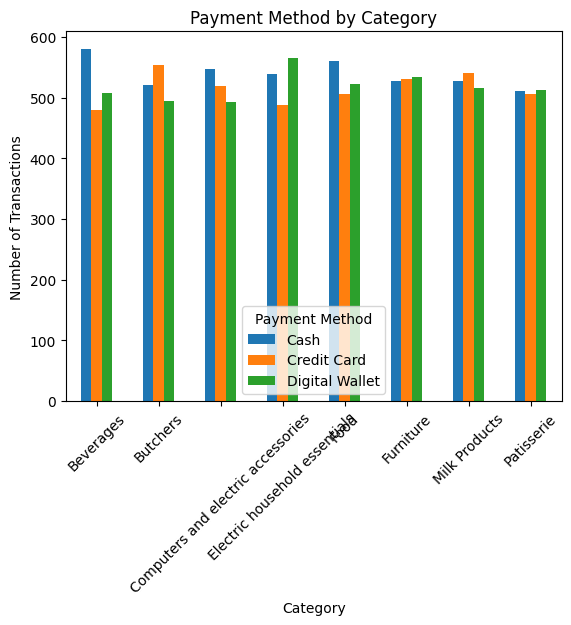

In [86]:
category_payment.plot(kind="bar")

plt.title("Payment Method by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()

Correlation Analysis : Correlation tells us the strength and direction of a relationship between two numerical variables.

-1  ←──────── 0 ────────→  +1

+1 → strong positive relationship
0 → little/no linear relationship
-1 → strong negative relationship

In [87]:
correlation = df[["Price Per Unit", "Quantity", "Total Spent"]].corr()

print(correlation)

                Price Per Unit  Quantity  Total Spent
Price Per Unit        1.000000  0.011801     0.630902
Quantity              0.011801  1.000000     0.712069
Total Spent           0.630902  0.712069     1.000000


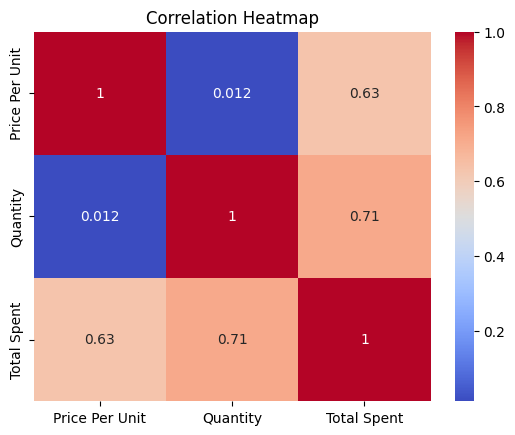

In [88]:
import seaborn as sns

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

Multivariate Analysis :

In [89]:
multivariate = df.groupby(
    ["Category", "Payment Method"]
)["Total Spent"].mean()

print(multivariate)

Category                            Payment Method
Beverages                           Cash              126.804152
                                    Credit Card       134.158643
                                    Digital Wallet    135.025773
Butchers                            Cash              146.743434
                                    Credit Card       137.940341
                                    Digital Wallet    132.447146
Computers and electric accessories  Cash              130.639155
                                    Credit Card       129.281633
                                    Digital Wallet    127.213519
Electric household essentials       Cash              131.295367
                                    Credit Card       129.858369
                                    Digital Wallet    141.519737
Food                                Cash              132.026515
                                    Credit Card       131.826763
                                    Dig

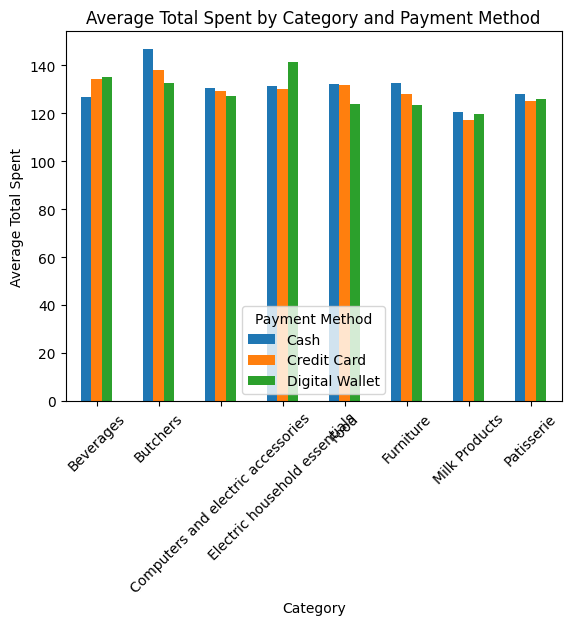

In [90]:
multivariate.unstack().plot(kind="bar")

plt.title("Average Total Spent by Category and Payment Method")
plt.xlabel("Category")
plt.ylabel("Average Total Spent")
plt.xticks(rotation=45)

plt.show()

What unstack() is doing
Our multivariate result has two grouping levels:
Category → Payment Method → Average Total Spent
unstack() rearranges it into a table-like structure so that the different Payment Methods become separate bars for each Category.

In [91]:
category_spending = df.groupby("Category")["Total Spent"].mean()

print(category_spending)

Category
Beverages                             131.716243
Butchers                              139.116310
Computers and electric accessories    129.107989
Electric household essentials         134.441623
Food                                  129.271400
Furniture                             128.072131
Milk Products                         119.042961
Patisserie                            126.416031
Name: Total Spent, dtype: float64


In [92]:
print("Category with highest average spending:")
print(category_spending.idxmax())

print("Highest average spending:")
print(category_spending.max())

Category with highest average spending:
Butchers
Highest average spending:
139.11631016042782


In [93]:
category_transactions = df["Category"].value_counts()

print(category_transactions)

Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64


In [94]:
max_transactions = category_transactions.max()

print("Highest number of transactions:")
print(max_transactions)

Highest number of transactions:
1591


In [95]:
payment_transactions = df["Payment Method"].value_counts()

print(payment_transactions)

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64


In [96]:
print(df["Transaction Date"].dtype)

datetime64[ns]


In [97]:
monthly_sales = df.groupby(
    df["Transaction Date"].dt.to_period("M")
)["Total Spent"].sum()

print(monthly_sales)

Transaction Date
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: Total Spent, dtype: float64


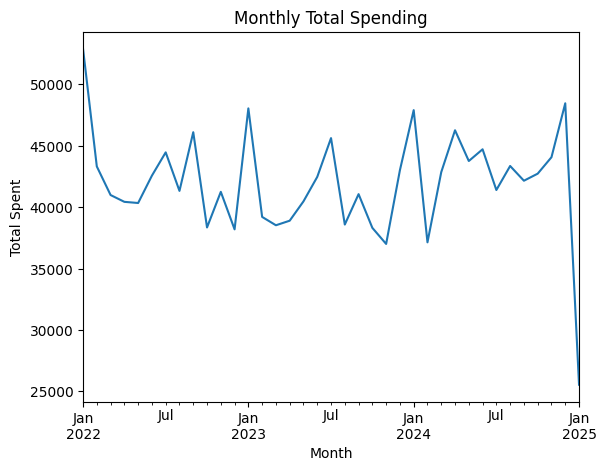

In [98]:
import matplotlib.pyplot as plt
monthly_sales.plot(kind="line")

plt.title("Monthly Total Spending")
plt.xlabel("Month")
plt.ylabel("Total Spent")

plt.show()

In [99]:
print("Highest monthly spending:", monthly_sales.max())
print("Month with highest spending:", monthly_sales.idxmax())

Highest monthly spending: 52911.5
Month with highest spending: 2022-01


In [100]:
location_spending = df.groupby("Location")["Total Spent"].mean()

print(location_spending)

Location
In-store    128.861596
Online      130.422050
Name: Total Spent, dtype: float64


In [101]:
df_clean = df.copy()

In [103]:
df_clean[df_clean["Discount Applied"].isna()][
    ["Transaction ID", "Total Spent", "Discount Applied"]
].head(10)

,Transaction ID,Total Spent,Discount Applied
3,TXN_9458126,247.5,NaN
5,TXN_7482416,200.0,NaN
14,TXN_2490363,55.0,NaN
15,TXN_1809665,NaN,NaN
17,TXN_9634894,275.0,NaN
20,TXN_9939063,126.0,NaN
21,TXN_8685338,105.0,NaN
22,TXN_6547964,66.5,NaN
33,TXN_1494700,315.0,NaN
34,TXN_1621497,NaN,NaN


In [104]:
missing_total = df_clean[
    df_clean["Total Spent"].isna() &
    df_clean["Price Per Unit"].notna() &
    df_clean["Quantity"].notna()
]

print(missing_total[[
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]].head(10))

print("Rows that can be calculated:", len(missing_total))

Empty DataFrame
Columns: [Price Per Unit, Quantity, Total Spent]
Index: []
Rows that can be calculated: 0


In [105]:
numeric_missing = df_clean[
    df_clean[["Price Per Unit", "Quantity", "Total Spent"]].isna().any(axis=1)
]

print("Rows with missing numeric values:", len(numeric_missing))

Rows with missing numeric values: 1213


In [106]:
missing_pattern = (
    df_clean[["Price Per Unit", "Quantity", "Total Spent"]]
    .isna()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

print(missing_pattern)

0    11362
1      609
2      604
Name: count, dtype: int64


In [107]:
missing_combinations = (
    df_clean[["Price Per Unit", "Quantity", "Total Spent"]]
    .isna()
    .astype(int)
    .value_counts()
)

print(missing_combinations)

Price Per Unit  Quantity  Total Spent
0               0         0              11362
1               0         0                609
0               1         1                604
Name: count, dtype: int64


In [108]:
price_missing = df_clean[
    df_clean["Price Per Unit"].isna()
]

price_missing["Calculated Price"] = (
    price_missing["Total Spent"] / price_missing["Quantity"]
)

print(price_missing[
    ["Price Per Unit", "Quantity", "Total Spent", "Calculated Price"]
].head(10))

     Price Per Unit  Quantity  Total Spent  Calculated Price
5               NaN      10.0        200.0              20.0
11              NaN       8.0         52.0               6.5
17              NaN      10.0        275.0              27.5
21              NaN       3.0        105.0              35.0
32              NaN       8.0        196.0              24.5
127             NaN      10.0        275.0              27.5
159             NaN       9.0        126.0              14.0
216             NaN       8.0         40.0               5.0
247             NaN       7.0        150.5              21.5
271             NaN       9.0         99.0              11.0


/tmp/ipykernel_581/4122317441.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_missing["Calculated Price"] = (


In [110]:
df_clean.loc[df_clean["Price Per Unit"].isna(), "Price Per Unit"] = (
    df_clean.loc[df_clean["Price Per Unit"].isna(), "Total Spent"]
    / df_clean.loc[df_clean["Price Per Unit"].isna(), "Quantity"]
)

In [111]:
print("Missing Price Per Unit:", df_clean["Price Per Unit"].isna().sum())

Missing Price Per Unit: 0


In [112]:
print("Rows with Quantity and Total Spent missing:", 604)
print("Percentage of dataset:", (604 / len(df_clean)) * 100)

Rows with Quantity and Total Spent missing: 604
Percentage of dataset: 4.8031809145129225


In [113]:
df_clean = df_clean.dropna(
    subset=["Quantity", "Total Spent"]
)

In [114]:
print("Rows after cleaning:", len(df_clean))

Rows after cleaning: 11971


In [115]:
item_missing = df_clean[df_clean["Item"].isna()]

print("Missing Item rows:", len(item_missing))
print(item_missing[
    ["Category", "Price Per Unit", "Quantity", "Total Spent"]
].head(10))

Missing Item rows: 609
                          Category  Price Per Unit  Quantity  Total Spent
5                       Patisserie            20.0      10.0        200.0
11                   Milk Products             6.5       8.0         52.0
17                   Milk Products            27.5      10.0        275.0
21                   Milk Products            35.0       3.0        105.0
32                            Food            24.5       8.0        196.0
127                       Butchers            27.5      10.0        275.0
159                       Butchers            14.0       9.0        126.0
216                     Patisserie             5.0       8.0         40.0
247  Electric household essentials            21.5       7.0        150.5
271                  Milk Products            11.0       9.0         99.0


In [116]:
df_clean["Item"] = df_clean["Item"].fillna("Unknown")

In [117]:
print("Missing Item:", df_clean["Item"].isna().sum())

Missing Item: 0


In [118]:
print("Final rows:", len(df_clean))
print("Final columns:", len(df_clean.columns))
print("\nRemaining missing values:")
print(df_clean.isna().sum())

Final rows: 11971
Final columns: 11

Remaining missing values:
Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    3988
dtype: int64


This below code will create:
retail_store_sales_cleaned.csv

In [119]:
df_clean.to_csv("retail_store_sales_cleaned.csv", index=False)

The below code for to run and download clean version

In [120]:
from google.colab import files

files.download("retail_store_sales_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final EDA Summary:
# Final EDA Summary

## Dataset Overview
- Original dataset: 12,575 rows and 11 columns
- Final cleaned dataset: 11,971 rows and 11 columns

## Data Cleaning
- Converted `Transaction Date` to datetime format.
- Reconstructed 609 missing `Price Per Unit` values using `Total Spent / Quantity`.
- Removed 604 rows where both `Quantity` and `Total Spent` were missing.
- Replaced 609 missing `Item` values with `"Unknown"`.
- Kept missing values in `Discount Applied` because their actual status could not be determined.
- Retained 60 valid high-value transactions with `Total Spent = 410`.

## Key Findings
- `Total Spent` was right-skewed, with a small number of high-value transactions.
- `Butchers` had the highest average spending among categories, at approximately 139.12.
- Online transactions had a slightly higher average spending (130.42) than in-store transactions (128.86).
- The highest monthly spending was 52,911.5 in January 2022.
- The identified outliers were valid transactions and were therefore retained.

## Conclusion
The EDA helped identify the main patterns, missing-value issues, outliers, and spending behavior in the retail sales dataset. After appropriate data cleaning and validation, the final dataset contains 11,971 records and is ready for further analysis and visualization.